In [1]:
import pandas as pd

#read the file with names classified with X and Y
df = pd.read_csv(
    "450_mb_ISCand Mwg.dat",
    delim_whitespace=True,
    header=None,
    names=["X", "Y"]
)

print(df.head())

     X         Y
0  4.5  4.636176
1  4.6  4.525882
2  4.6  4.636176
3  4.6  4.525882
4  4.7  4.525882


C:\Users\matias.DESKTOP-VU2DMIJ.000\AppData\Local\Temp\ipykernel_16988\2023769894.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


In [13]:
from sklearn.linear_model import LinearRegression
import numpy as np

#Select X columns
X = df["X"].values.reshape(-1,1)
#Select Y columns
Y = df["Y"].values

#use Linear Regression
modelo = LinearRegression()
#transform
modelo.fit(X, Y)

#print the values B1, B0 and R2
print("Pendiente (β₁):", modelo.coef_[0])
print("Intercepto (β₀):", modelo.intercept_)
print("R²:", modelo.score(X, Y))

Pendiente (β₁): 1.1887766879101782
Intercepto (β₀): -1.2079044601685256
R²: 0.7484034751415671


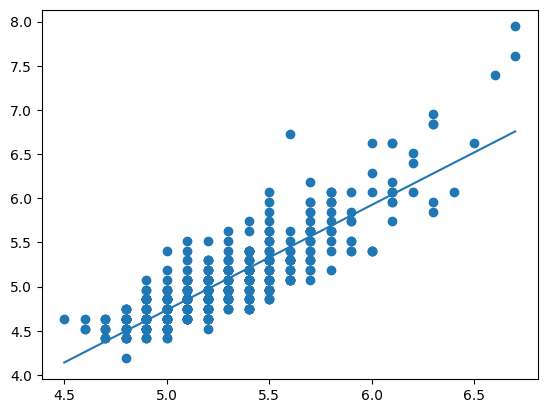

In [14]:
import matplotlib.pyplot as plt

#draw the graphical using linearRegression
plt.scatter(X, Y)
plt.plot(X, modelo.predict(X))
plt.show()

In [15]:
#predict values
Y_pred = modelo.predict(X)
Y_pred

array([4.14159064, 4.2604683 , 4.2604683 , 4.2604683 , 4.37934597,
       4.37934597, 4.37934597, 4.37934597, 4.37934597, 4.37934597,
       4.37934597, 4.37934597, 4.37934597, 4.49822364, 4.49822364,
       4.49822364, 4.49822364, 4.49822364, 4.49822364, 4.49822364,
       4.49822364, 4.49822364, 4.49822364, 4.49822364, 4.49822364,
       4.49822364, 4.49822364, 4.49822364, 4.49822364, 4.49822364,
       4.49822364, 4.49822364, 4.49822364, 4.49822364, 4.49822364,
       4.49822364, 4.49822364, 4.49822364, 4.49822364, 4.49822364,
       4.49822364, 4.49822364, 4.61710131, 4.61710131, 4.61710131,
       4.61710131, 4.61710131, 4.61710131, 4.61710131, 4.61710131,
       4.61710131, 4.61710131, 4.61710131, 4.61710131, 4.61710131,
       4.61710131, 4.61710131, 4.61710131, 4.61710131, 4.61710131,
       4.61710131, 4.61710131, 4.61710131, 4.61710131, 4.61710131,
       4.61710131, 4.61710131, 4.61710131, 4.61710131, 4.61710131,
       4.61710131, 4.61710131, 4.61710131, 4.61710131, 4.61710

In [16]:
#Calculate residuals
residuos = Y - Y_pred
residuos

array([ 0.49458584,  0.26541405,  0.37570817,  0.26541405,  0.14653638,
        0.2568305 ,  0.2568305 ,  0.2568305 ,  0.03624226,  0.03624226,
        0.14653638,  0.14653638,  0.03624226, -0.30322364,  0.13795283,
        0.24824695,  0.13795283,  0.13795283,  0.24824695,  0.13795283,
        0.02765871,  0.13795283,  0.13795283,  0.13795283,  0.13795283,
       -0.08263541,  0.02765871,  0.24824695,  0.13795283,  0.13795283,
        0.02765871,  0.24824695,  0.13795283, -0.08263541,  0.13795283,
       -0.08263541, -0.08263541,  0.13795283,  0.02765871,  0.02765871,
       -0.08263541,  0.13795283,  0.12936928,  0.46025163,  0.12936928,
        0.2396634 ,  0.12936928,  0.01907516,  0.12936928, -0.09121896,
        0.2396634 , -0.20151308,  0.01907516,  0.34995751,  0.34995751,
        0.2396634 ,  0.2396634 ,  0.01907516,  0.01907516,  0.01907516,
       -0.09121896,  0.01907516, -0.20151308,  0.12936928, -0.09121896,
        0.2396634 , -0.20151308, -0.09121896, -0.09121896, -0.09

In [17]:
from sklearn.metrics import mean_squared_error

#calculates mse (medium square error)
mse = mean_squared_error(Y, Y_pred)
mse

0.0659112190890245

In [18]:
import numpy as np

#Calcula la raiz cuadratica del error rmse = raiz(mse)
rmse = np.sqrt(mse)
rmse

np.float64(0.2567318038128983)

In [19]:
from sklearn.metrics import mean_absolute_error

#calcula el error cuadrático absoluto
mae = mean_absolute_error(Y, Y_pred)
mae

0.19359671111431845

In [20]:
from sklearn.metrics import explained_variance_score

#calcula el puntaje de varianza explicada, en otras palabras, calcula cúanto mide la variabilidad
ev = explained_variance_score(Y, Y_pred)
ev

0.7484034751415671

In [21]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: C:\Users\matias.DESKTOP-VU2DMIJ.000\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [22]:
import statsmodels.api as sm

#Es usado para para ajustar una regresión lineal por mínimos cuadrados ordinarios (OLS = Ordinary Least Squares) 
#y mostrar un resumen estadístico completo del modelo
#crea un modelo de regrasion lineal Y=b0+b1X+error
X_sm = sm.add_constant(X)
modelo_sm = sm.OLS(Y, X_sm).fit()

print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     1333.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          2.49e-136
Time:                        13:02:28   Log-Likelihood:                -26.647
No. Observations:                 450   AIC:                             57.29
Df Residuals:                     448   BIC:                             65.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2079      0.173     -6.990      0.0

In [23]:
import numpy as np

#y de ese modelo se predicen los valores y se calculan las variables
Y_pred = modelo.predict(X)

ss_res = np.sum((Y - Y_pred)**2)
ss_tot = np.sum((Y - np.mean(Y))**2)

r2 = 1 - (ss_res / ss_tot)

print("R²:", r2)

R²: 0.7484034751415671
